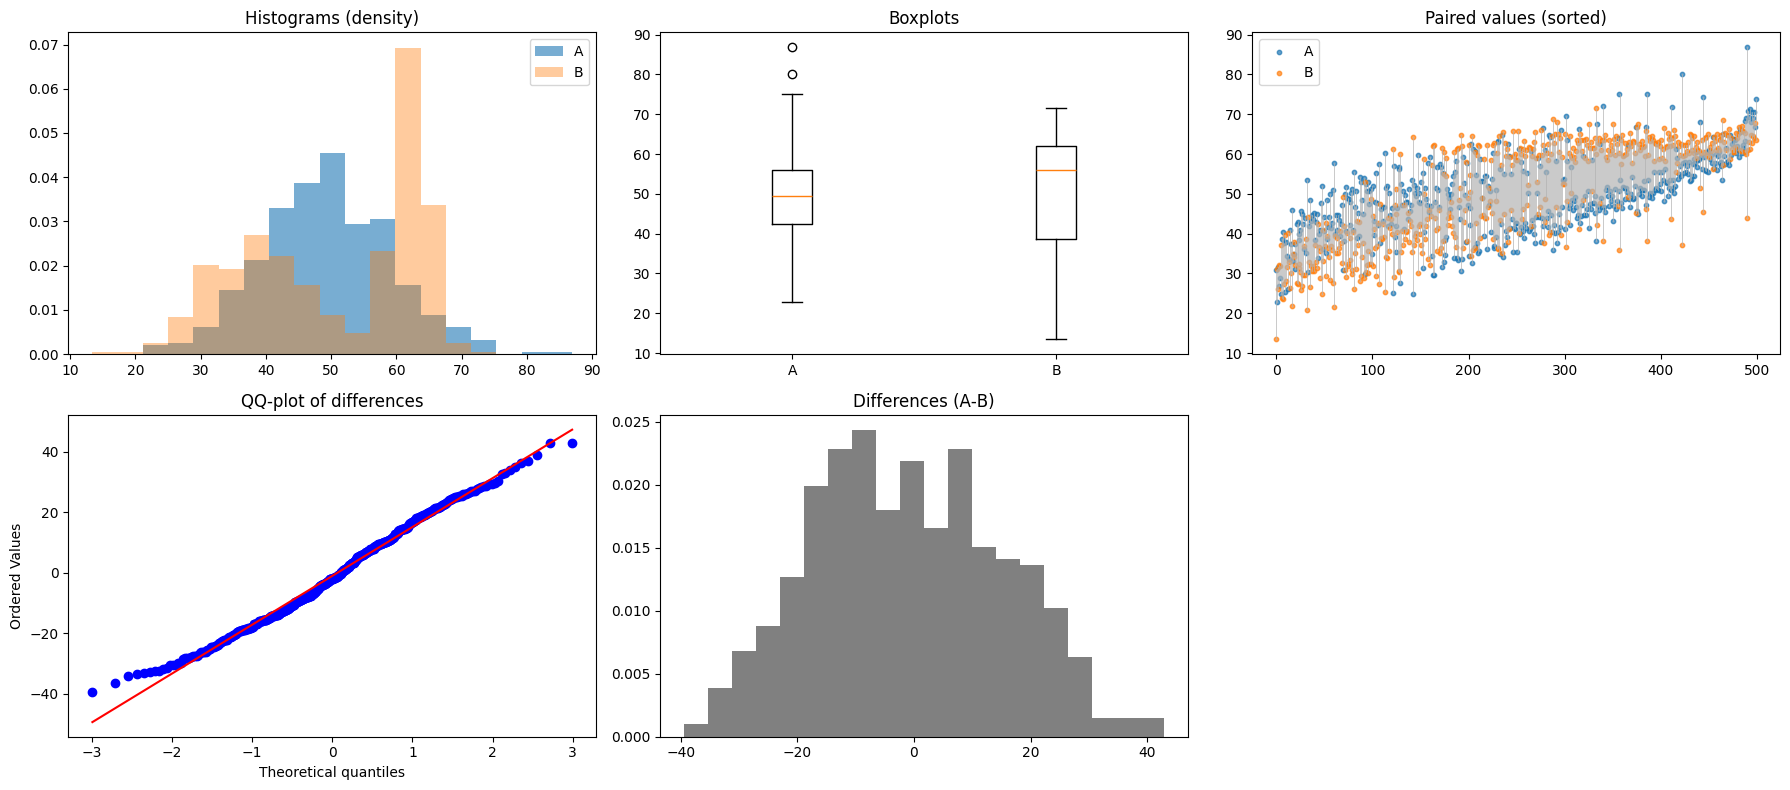

Wilcoxon signed‑rank: p=0.1205, n=500, mean(A)=49.4, mean(B)=50.4, mean(diff)=-0.977, Hodges‑Lehmann=-1.94, HL_CI=(-3.67, 0.203), bootstrap_median_CI=(-3.67, 0.203), Cohen's d=-0.0604, r=0.0694
Are columns A and B significantly different? No
No


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# ---------- Config ----------
ALPHA = 0.05
SEED = 12345
N_BOOT = 5000
OUT_DIR = Path("display_output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Load data ----------
csv_path = Path("input_data/data.csv")
df = pd.read_csv(csv_path, usecols=["A", "B"]).dropna()
n = len(df)
if n < 2:
    raise ValueError("Need at least two paired observations.")

# ---------- Summary ----------
a = df["A"].to_numpy()
b = df["B"].to_numpy()
diff = a - b
mean_a, mean_b = a.mean(), b.mean()
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)

# ---------- Normality ----------
shapiro_p = None
if 3 <= n <= 5000:
    shapiro_p = float(stats.shapiro(diff).pvalue)

# ---------- Parametric test (always computed) ----------
t_stat, t_p = stats.ttest_rel(a, b, nan_policy="omit")
t_stat, t_p = float(t_stat), float(t_p)

# ---------- Choose final test ----------
if shapiro_p is not None and shapiro_p < ALPHA:
    if np.allclose(diff, 0):
        chosen_test = "No difference (all diffs zero)"
        chosen_p = 1.0
        test_stat = 0.0
        hl_est, hl_ci = np.median(diff), (np.median(diff), np.median(diff))
    else:
        # Wilcoxon signed‑rank
        w_res = stats.wilcoxon(diff, zero_method="pratt", alternative="two-sided")
        chosen_test = "Wilcoxon signed‑rank"
        test_stat, chosen_p = float(w_res.statistic), float(w_res.pvalue)

        # Hodges–Lehmann estimate (fallback to bootstrap median CI if unavailable)
        try:
            hl_res = stats.hodgeslehmann(a, b, method="wilcox")
            hl_est = hl_res[0]
            hl_ci = hl_res[1]
        except Exception:
            # bootstrap median CI
            rng = np.random.default_rng(SEED)
            boot_medians = [
                np.median(rng.choice(diff, size=n, replace=True)) for _ in range(N_BOOT)
            ]
            hl_est = np.median(diff)
            hl_ci = (np.percentile(boot_medians, 2.5), np.percentile(boot_medians, 97.5))
else:
    chosen_test = "Paired t-test"
    test_stat, chosen_p = t_stat, t_p
    hl_est, hl_ci = np.nan, (np.nan, np.nan)

# ---------- Effect sizes ----------
cohen_d = mean_diff / sd_diff if sd_diff != 0 else np.nan
r = np.nan
if chosen_test.startswith("Wilcoxon") and n > 20:
    # normal approximation for Wilcoxon
    W = test_stat
    mean_W = n * (n + 1) / 4
    var_W = n * (n + 1) * (2 * n + 1) / 24
    z = (W - mean_W) / np.sqrt(var_W)
    r = abs(z) / np.sqrt(n)

# ---------- Bootstrap CIs (mean & median) ----------
rng = np.random.default_rng(SEED)
boot_means, boot_medians = [], []
for _ in range(N_BOOT):
    sample = rng.choice(diff, size=n, replace=True)
    boot_means.append(sample.mean())
    boot_medians.append(np.median(sample))
boot_ci_mean = (np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5))
boot_ci_median = (np.percentile(boot_medians, 2.5), np.percentile(boot_medians, 97.5))

# ---------- Parametric CI for mean difference ----------
se_diff = sd_diff / np.sqrt(n)
ci_mean_param = stats.t.interval(0.95, df=n - 1, loc=mean_diff, scale=se_diff)

# ---------- Diagnostics plots ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.ravel()

# 1) Histograms
bins = np.histogram_bin_edges(np.concatenate([a, b]), bins="auto")
axes[0].hist(a, bins=bins, alpha=0.6, label="A", density=True)
axes[0].hist(b, bins=bins, alpha=0.4, label="B", density=True)
axes[0].set_title("Histograms (density)")
axes[0].legend()

# 2) Boxplots
axes[1].boxplot([a, b], tick_labels=["A", "B"])
axes[1].set_title("Boxplots")

# 3) Paired lines (sorted by pair mean, jitter)
order = np.argsort((a + b) / 2)
x = np.arange(n)
jitter = 0.2
axes[2].scatter(
    x + rng.uniform(-jitter, jitter, n), a[order], s=10, label="A", alpha=0.7
)
axes[2].scatter(
    x + rng.uniform(-jitter, jitter, n), b[order], s=10, label="B", alpha=0.7
)
for i, (ai, bi) in enumerate(zip(a[order], b[order])):
    axes[2].plot([i, i], [ai, bi], color="0.7", linewidth=0.5)
axes[2].set_title("Paired values (sorted)")
axes[2].legend()

# 4) QQ‑plot of differences
stats.probplot(diff, plot=axes[3])
axes[3].set_title("QQ‑plot of differences")

# 5) Difference histogram
axes[4].hist(diff, bins=20, color="gray", density=True)
axes[4].set_title("Differences (A‑B)")

# 6) Blank (for layout)
axes[5].axis("off")

plt.tight_layout()
diag_path = OUT_DIR / "AB_diagnostics.png"
fig.savefig(diag_path, dpi=150)
plt.show()

# ---------- Reporting ----------
ci_text = (
    f"parametric_mean_CI=({ci_mean_param[0]:.3g}, {ci_mean_param[1]:.3g})"
    if chosen_test.startswith("Paired t") 
    else f"Hodges‑Lehmann={hl_est:.3g}, HL_CI=({hl_ci[0]:.3g}, {hl_ci[1]:.3g}), "
         f"bootstrap_median_CI=({boot_ci_median[0]:.3g}, {boot_ci_median[1]:.3g})"
)

print(
    f"{chosen_test}: p={chosen_p:.4g}, n={n}, mean(A)={mean_a:.3g}, mean(B)={mean_b:.3g}, "
    f"mean(diff)={mean_diff:.3g}, {ci_text}, Cohen's d={cohen_d:.3g}, r={r:.3g}"
)

# decision description (second‑last print)
decision = "Yes" if chosen_p < ALPHA else "No"
print(f"Are columns A and B significantly different? {decision}")

# final result (last print)
print(decision)

# ---------- Save final result ----------
final_path = OUT_DIR / "final_result.txt"
with open(final_path, "w") as f:
    f.write(decision)
